URL index: [Home](https://zzz.bwh.harvard.edu/luna-walkthrough/) | [Data](https://zzz.bwh.harvard.edu/luna-walkthrough/data/) | [S1. File QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p1/) | [S2. Signal QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p2) | [S3. Staging](https://zzz.bwh.harvard.edu/luna-walkthrough/p3) | [S4. Artifacts](https://zzz.bwh.harvard.edu/luna-walkthrough/p4) | [S5. Analysis](https://zzz.bwh.harvard.edu/luna-walkthrough/p5)

Notebook index: [Index](../00_index.ipynb) | [S1. File QC](../p1/00_index.ipynb) | [S2. Signal QC](../p2/00_index.ipynb) | [S3. Staging](../p3/00_index.ipynb) | [S4. Artifacts](../p4/00_index.ipynb) | [S5. Analysis](../p5/00_index.ipynb)

---

# 3.4. Automated staging (POPS)

Walkthrough URL = [https://zzz.bwh.harvard.edu/luna-walkthrough/p3/pops/](https://zzz.bwh.harvard.edu/luna-walkthrough/p3/pops/)

Here we'll use Luna's `POPS` stager, with a focus on the default single central EEG adult model (called `s2`), included in the `auxiliary/` folder of this walkthrough. The `s2` model was trained on over 3000 central EEG leads from NSRR recordings.

In [4]:
import lunapi as lp
proj = lp.proj()

initiated lunapi v1.2.3 <lunapi.lunapi0.luna object at 0x12a287270> 



## Obtaining the POPS model(s)

We can use the `RUN-POPS` Luna command to apply this model to our sample. `RUN-POPS` currently assumes the `s2` model by default, so we only need to point to the folder we've just created with the `s2` model files and tell it to use the EEG C4 channel. (This model was trained on C3 and C4 channels.)

To clarify the presentation and evaluation of `POPS`, we'll apply it to the original (`v1`) dataset rather than the manipulated `v2` dataset. Also, the `s2` model was trained on central EEGs with contra-lateral mastoid rereferencing whereas the `harm1.lst` datasets are now linked-mastoid referenced (although we don't expect this to make any major differences in performance).

We'll use `s.lst` that points to the `v1` data and tell `RUN-POPS` to re-reference to contra-lateral mastoids (i.e. to use C4-A1):

In [2]:
proj.build( [ '../luna-grins/v1/edfs' , '../luna-grins/v1/annots' ] ) 

20

In [5]:
proj.sample_list()

,ID,EDF,Annotations
1,F01,../luna-grins/v1/edfs/F01.edf,{../luna-grins/v1/annots/F01.annot}
2,F02,../luna-grins/v1/edfs/F02.edf,{../luna-grins/v1/annots/F02.annot}
3,F03,../luna-grins/v1/edfs/F03.edf,{../luna-grins/v1/annots/F03.annot}
4,F04,../luna-grins/v1/edfs/F04.edf,{../luna-grins/v1/annots/F04.annot}
5,F05,../luna-grins/v1/edfs/F05.edf,{../luna-grins/v1/annots/F05.annot}
6,F06,../luna-grins/v1/edfs/F06.edf,{../luna-grins/v1/annots/F06.annot}
7,F07,../luna-grins/v1/edfs/F07.edf,{../luna-grins/v1/annots/F07.annot}
8,F08,../luna-grins/v1/edfs/F08.edf,{../luna-grins/v1/annots/F08.annot}
9,F09,../luna-grins/v1/edfs/F09.edf,{../luna-grins/v1/annots/F09.annot}
10,F10,../luna-grins/v1/edfs/F10.edf,{../luna-grins/v1/annots/F10.annot}


## Single channel prediction

This will take a little while to run (on this laptop, for all 20 individuals the above completed in about a minute or so when based on this single EEG channel.)

In [8]:
# luna s.lst -o out.db -s RUN-POPS sig=C4 ref=A1 path=work/data/auxilary/pops
res = proj.silent_proc( 'RUN-POPS sig=C4 ref=A1 path=../work/data/auxiliary/pops' ) 

In [11]:
# destrat out.db +RUN-POPS -v K K3 ACC ACC3 -p 2 
tbl = proj.table( 'RUN_POPS' )[[ 'ID' , 'K' , 'K3' , 'ACC' , 'ACC3' ]]
tbl

,ID,K,K3,ACC,ACC3
0,F01,0.805933,0.804233,0.857651,0.897983
1,F02,0.788407,0.822563,0.853659,0.915215
2,F03,0.735338,0.794868,0.804598,0.898851
3,F04,0.734633,0.777254,0.793802,0.873659
4,F05,0.684487,0.829005,0.762277,0.91183
5,F06,0.734272,0.776836,0.820073,0.906977
6,F07,0.604105,0.729738,0.711864,0.832627
7,F08,0.778125,0.862841,0.83848,0.931116
8,F09,0.751229,0.870901,0.843389,0.944801
9,F10,0.810059,0.925591,0.86645,0.960912


Overall, performance is good: the median (mean) 5-class kappa is 0.74 (0.73). The median (mean) 3-class kappa is 0.80 (0.78).

In [19]:
import pandas as pd

def safe_to_numeric(col):
    try: return pd.to_numeric(col)
    except Exception: return col

tbl = tbl.apply( safe_to_numeric )

tbl.median(numeric_only = True )

K       0.740061
K3      0.797318
ACC     0.826881
ACC3    0.902914
dtype: float64

In [20]:
tbl.mean(numeric_only = True )

K       0.730543
K3      0.779715
ACC     0.814904
ACC3    0.898317
dtype: float64

## Multiple channels

Given we have hd-EEG, we'll apply the same model to six channels per individual: in addition to C4, we will add the adjacent FC4 and CP4 channels, as well as the corresponding contra-lateral left hemisphere channels:

In [27]:
# luna s.lst -o out.db \
# -s ' RUN-POPS sig=C4,CP4,FC4,C3,CP3,FC3 ref=A1,A1,A1,A2,A2,A2
#               path=work/data/auxiliary/pops args="mean" ' 

res = proj.proc( 'RUN-POPS sig=C4,CP4,FC4,C3,CP3,FC3'
                + ' ref=A1,A1,A1,A2,A2,A2'
                + ' path=../work/data/auxiliary/pops'
                + ' args="mean" ' )

# nb. multi-line statement but with individual commands split over multiple lines
#  --> currently requires this type of parsing; will be made similar to Luna cmd-line
#      scripts in next release, i.e.: this form would also work , w/ the ellipses:

#res = proj.proc( ''' RUN-POPS sig=C4,CP4,FC4,C3,CP3,FC3
#                      ... ref=A1,A1,A1,A2,A2,A2
#                      ... path=../work/data/auxiliary/pops
#                      ... args="mean" ''' )



In [31]:
# destrat out.db +RUN-POPS -v K K3 ACC ACC3 -p 2 
tbl = proj.table( 'RUN_POPS' )[[ 'ID', 'K', 'K3', 'ACC', 'ACC3' ]]
tbl

,ID,K,K3,ACC,ACC3
0,F01,0.815489,0.828881,0.864769,0.911032
1,F02,0.78352,0.814878,0.850174,0.911731
2,F03,0.739204,0.797942,0.806897,0.9
3,F04,0.780006,0.850123,0.830751,0.914184
4,F05,0.690233,0.828228,0.766741,0.91183
5,F06,0.778536,0.794269,0.853121,0.915545
6,F07,0.659425,0.784768,0.755297,0.867585
7,F08,0.773761,0.837426,0.834917,0.918052
8,F09,0.753586,0.848415,0.845956,0.934531
9,F10,0.813083,0.916871,0.871676,0.959538


The mean _K_ is now slightly higher (versus 0.73 above):

In [32]:
tbl = tbl.apply( safe_to_numeric )

tbl.mean(numeric_only = True )

K       0.748234
K3      0.800283
ACC     0.828218
ACC3    0.907468
dtype: float64

## Reviewing outputs

We can extract epoch-level predictions from the previous multi-channel run.  Here we'll use built in lunapi functions to plot the hypno-densities, the predicted and original hypnograms.

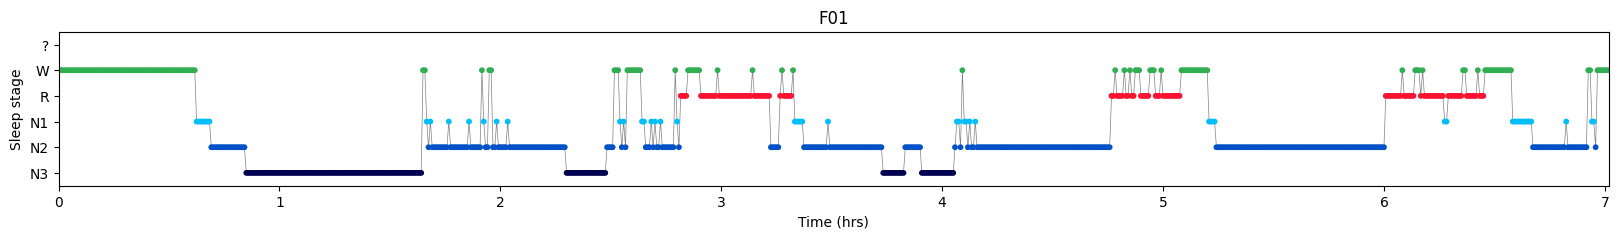

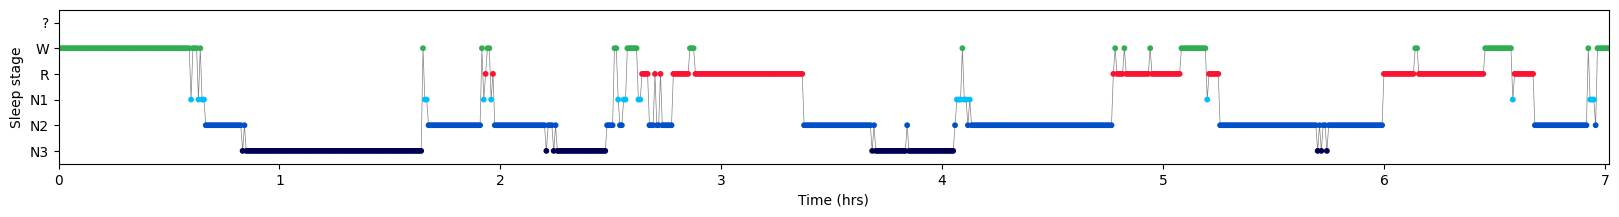

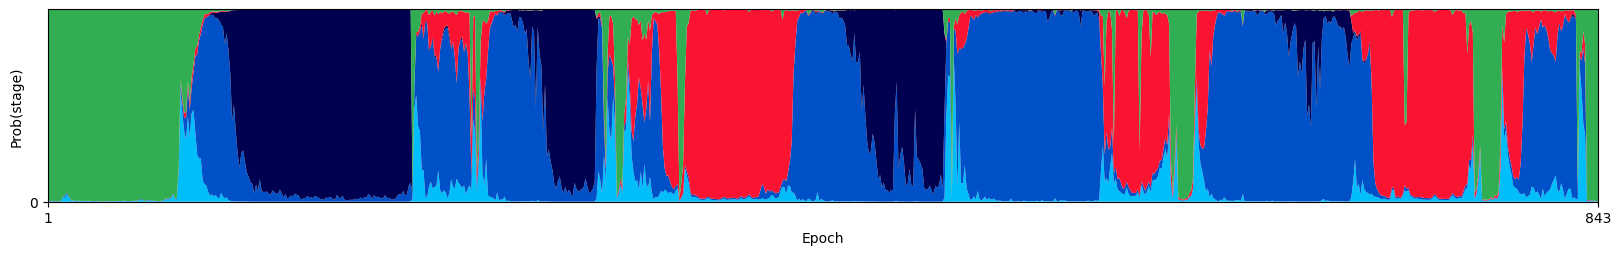

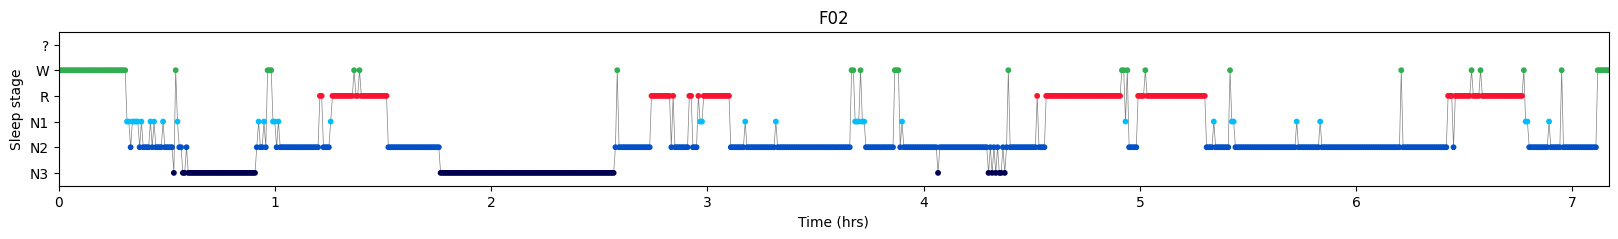

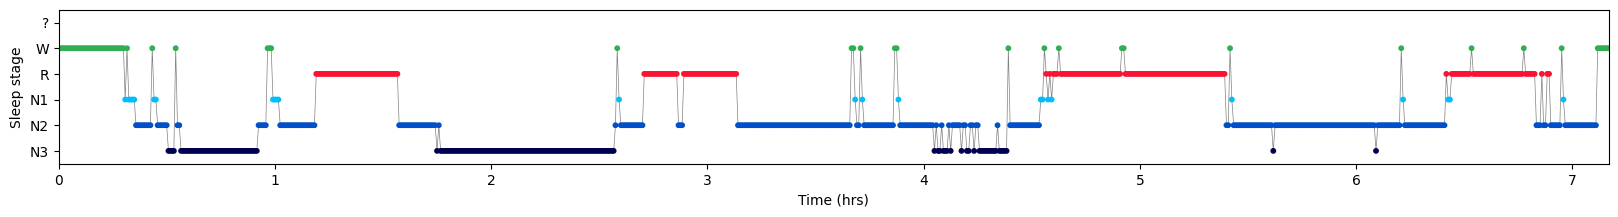

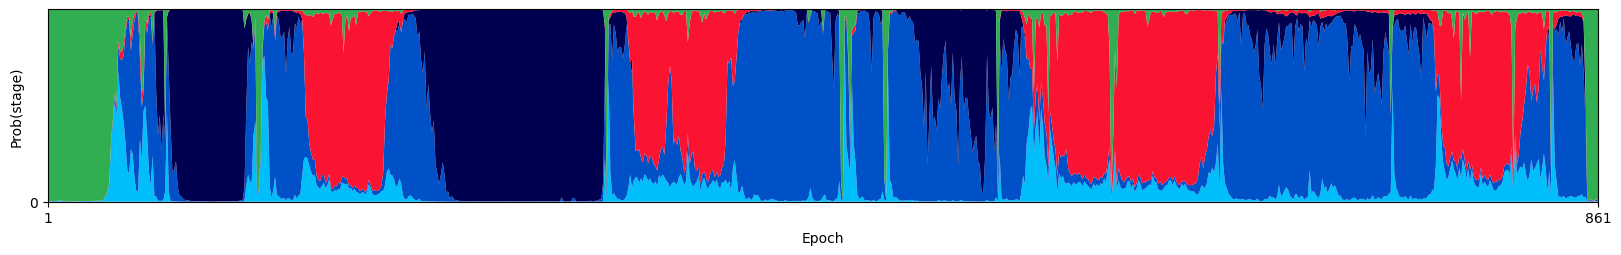

In [41]:
df = proj.table( 'RUN_POPS' , 'E' )
ids = df.ID.unique()

# we'll run this just for the first two individuals here:

for id in ids[:2]:
    lp.hypno( df.PRIOR[ df.ID == id ] , title = id )
    lp.hypno( df.PRED[ df.ID == id ] )
    lp.hypno_density( df[ df.ID == id ] , title = id )


---
We're now ready to move to the next section, for the [final steps of QC](../p4/00_index.ipynb)